# Credit Card Fraud Detection Using Unsupervised Anomaly Detection

## Research Context
Financial fraud detection is a high-impact anomaly detection problem where fraudulent events are extremely rare compared with legitimate transactions. This notebook investigates whether unsupervised methods can separate rare fraudulent behavior from normal transaction patterns.

## Study Objective
- Build a professional end-to-end anomaly detection workflow.
- Compare `Isolation Forest` and `One-Class SVM` under class imbalance.
- Interpret model behavior with statistical and visual analysis.
- Derive practical, business-oriented insights from the detected anomalies.

## Research Questions
1. Does the dataset contain strong imbalance and outlier structure consistent with fraud detection assumptions?
2. Which unsupervised algorithm provides a better trade-off between fraud recall and false alarms?
3. What behavioral patterns (amount/time) distinguish detected anomalies?

## Reproducibility Note
All steps are presented sequentially: data loading, EDA, preprocessing, representation analysis (PCA), model training, evaluation, and interpretation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility and visual consistency
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 1. Data Acquisition and Initial Inspection

We begin by loading the transaction dataset and performing first-pass diagnostics to verify schema, data types, and descriptive statistics. This step establishes data integrity before any transformation.

### Why this step matters
- Detect potential data quality issues early.
- Confirm presence and role of the target label (`Class`) for offline evaluation.
- Understand basic feature scale differences that motivate normalization.

In [2]:
df = pd.read_csv('creditcard.csv')


In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
# Drop rows with any missing values
df.dropna(inplace=True)

# Verify that the missing values have been removed
display(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## 2. Exploratory Data Analysis (EDA): Amount and Time Distributions

This section examines raw marginal distributions of transaction amount and transaction time to identify skewness, cyclicity, and outlier behavior.

### Analytical intent
- Evaluate whether heavy-tail behavior exists in `Amount`.
- Inspect temporal periodicity in `Time`.
- Build intuition for why anomaly detection is suitable.

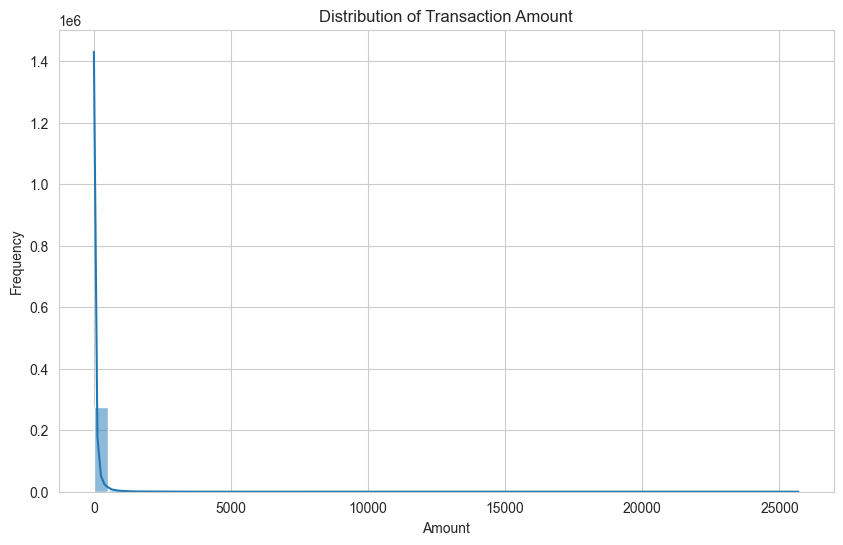

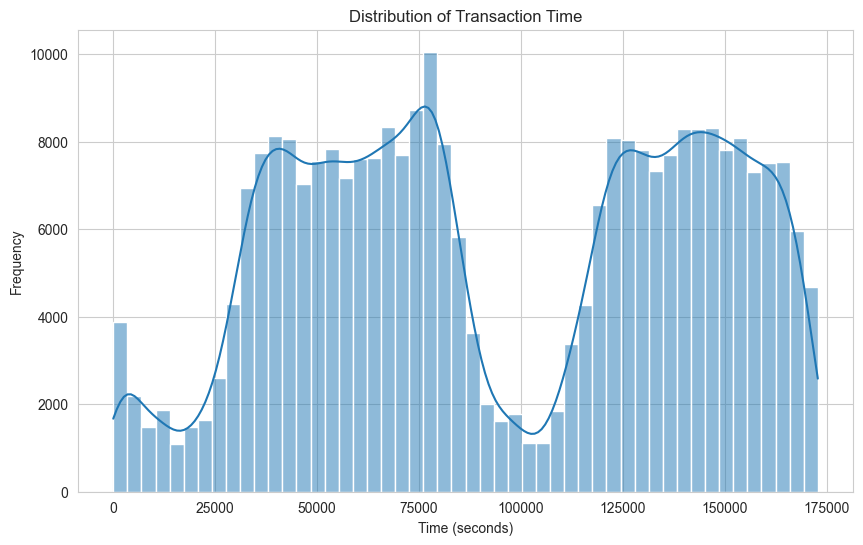

In [8]:
#Distribution of Amount
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Distribution of Time
plt.figure(figsize=(10, 6))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribution of Transaction Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()



### Interpretation: Transaction Amount

- **Strong right-skew:** most transactions are low-value, with a long tail of high-value events.
- **Outlier regime:** the upper tail likely contains both legitimate rare purchases and potentially fraudulent behavior.
- **Modeling implication:** anomaly detectors should avoid over-penalizing all large transactions; amount is informative but not sufficient in isolation.

From a research perspective, this validates a key assumption: fraud may appear as low-density behavior in feature space, but not every low-density point is fraud.

### Interpretation: Transaction Time

- **Bimodal temporal activity:** two peaks indicate recurring high-activity periods.
- **Behavioral cyclicity:** transaction behavior likely follows human daily rhythms.
- **Anomaly signal potential:** transactions occurring in low-activity windows may carry stronger anomaly evidence.

This supports incorporating temporal context in post-model interpretation and potentially in future feature engineering.

## 3. Class Imbalance Assessment

Fraud detection datasets are typically extremely imbalanced. Quantifying this imbalance is critical because standard accuracy can be misleading and anomaly detectors must be interpreted with recall/precision trade-offs in mind.

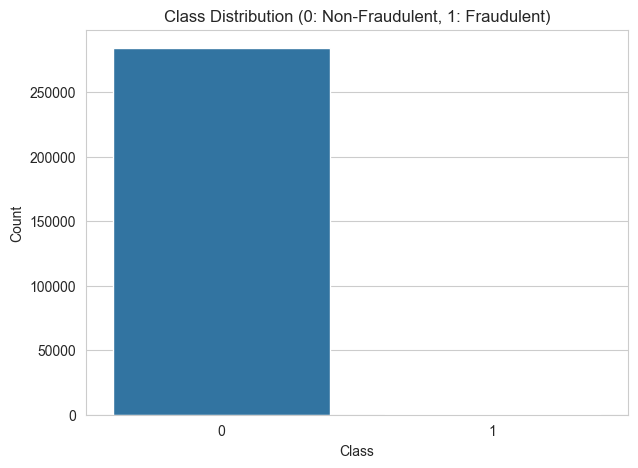

Non-fraud count: 284,315
Fraud count: 492
Fraud ratio: 0.1727%


In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Non-Fraudulent, 1: Fraudulent)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

class_counts = df['Class'].value_counts().sort_index()
fraud_ratio = class_counts[1] / class_counts.sum()
print(f"Non-fraud count: {class_counts[0]:,}")
print(f"Fraud count: {class_counts[1]:,}")
print(f"Fraud ratio: {fraud_ratio:.4%}")

The plot confirms extreme class imbalance, with fraudulent transactions representing a very small minority.

### Why this is critical
- Accuracy alone is not an appropriate metric.
- Model evaluation must emphasize minority-class recall and precision.
- Operationally, false positives and false negatives have asymmetric costs.

## 4. Data Preprocessing and Feature Standardization

Unsupervised distance- and boundary-based methods are sensitive to feature scale. We standardize numerical predictors so each feature contributes comparably to model learning.

### Methodological note
The label column (`Class`) is excluded from scaling to avoid target leakage into transformed inputs.

In [10]:
# Create a copy of the dataframe to avoid modifying the original one
data = df.copy()

# Get the column names to be scaled (all columns except 'Class')
columns_to_scale = data.columns[data.columns != 'Class']

# Scale the selected columns
scaler = StandardScaler()
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

# Display the first few rows of the scaled data
display(data.head())

# Now, we will separate the features (X) from the target (y)
# We will use 'y' later to evaluate the performance of our unsupervised models
X = data.drop('Class', axis=1)
y_true = data['Class']

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-0.694242,-0.044075,1.672773,0.973366,-0.245117,0.347068,0.193679,0.082637,0.331128,...,-0.024923,0.382854,-0.176911,0.110507,0.246585,-0.392170,0.330892,-0.063781,0.244964,0
1,-1.996583,0.608496,0.161176,0.109797,0.316523,0.043483,-0.061820,-0.063700,0.071253,-0.232494,...,-0.307377,-0.880077,0.162201,-0.561131,0.320694,0.261069,-0.022256,0.044608,-0.342475,0
2,-1.996562,-0.693500,-0.811578,1.169468,0.268231,-0.364572,1.351454,0.639776,0.207373,-1.378675,...,0.337632,1.063358,1.456320,-1.138092,-0.628537,-0.288447,-0.137137,-0.181021,1.160686,0
3,-1.996562,-0.493325,-0.112169,1.182516,-0.609727,-0.007469,0.936150,0.192071,0.316018,-1.262503,...,-0.147443,0.007267,-0.304777,-1.941027,1.241904,-0.460217,0.155396,0.186189,0.140534,0
4,-1.996541,-0.591330,0.531541,1.021412,0.284655,-0.295015,0.071999,0.479302,-0.226510,0.744326,...,-0.012839,1.100011,-0.220123,0.233250,-0.395202,1.041611,0.543620,0.651816,-0.073403,0


## 5. Correlation Structure Analysis

A full-feature correlation map helps assess redundancy and potential multicollinearity patterns in the transformed space. While tree-based anomaly methods can handle correlated features better than linear methods, this diagnostic remains important for model interpretation.

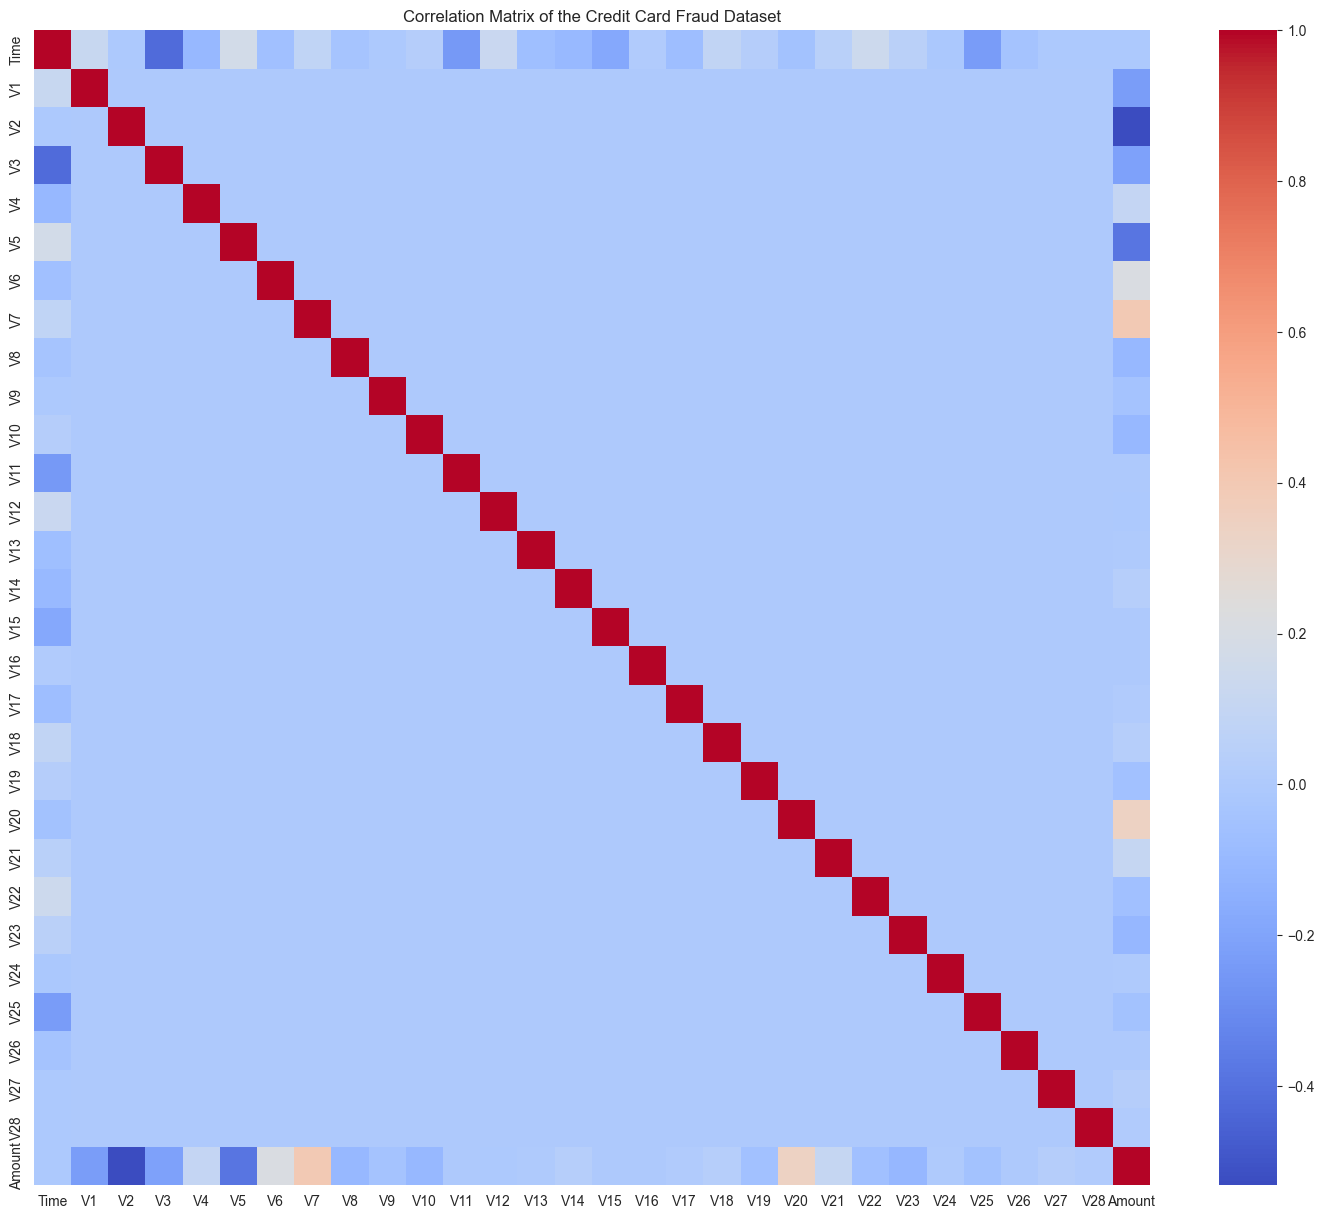

In [11]:
# Calculate the correlation matrix
corr_matrix = X.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of the Credit Card Fraud Dataset')
plt.show()

## 6. Dimensionality Reduction for Representation Diagnostics

To visually inspect separability between normal and fraudulent behavior, we project high-dimensional data into a lower-dimensional manifold using PCA.

This is used for *interpretability and diagnostics*, not as a mandatory preprocessing step for model training.

For representation diagnostics, PCA is used to project standardized features into 3 components for qualitative visualization.

### Important methodological clarification
PCA in this notebook is used to inspect structure and potential class separation. The anomaly models are still trained on the full standardized feature space.

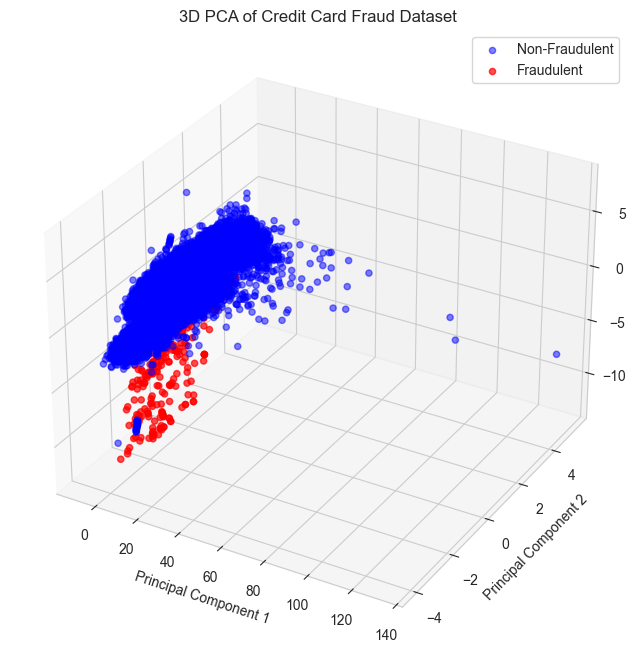

In [13]:
# Create a 3D PCA projection dataframe for the diagnostic plot
# (Needed because later code expects df_pca_3d and its PCA column names.)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

df_pca_3d = pd.DataFrame(
    X_pca_3d,
    columns=[
        'principal component 1',
        'principal component 2',
        'principal component 3',
    ],
)
# y_true was created earlier in preprocessing
df_pca_3d['Class'] = y_true.to_numpy()

# Plot the PCA results in 3D with a legend
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for non-fraudulent transactions
ax.scatter(
    df_pca_3d[df_pca_3d['Class'] == 0]['principal component 1'],
    df_pca_3d[df_pca_3d['Class'] == 0]['principal component 2'],
    df_pca_3d[df_pca_3d['Class'] == 0]['principal component 3'],
    c='blue',
    label='Non-Fraudulent',
    alpha=0.5,
)

# Scatter plot for fraudulent transactions
ax.scatter(
    df_pca_3d[df_pca_3d['Class'] == 1]['principal component 1'],
    df_pca_3d[df_pca_3d['Class'] == 1]['principal component 2'],
    df_pca_3d[df_pca_3d['Class'] == 1]['principal component 3'],
    c='red',
    label='Fraudulent',
    alpha=0.7,
)

ax.set_title('3D PCA of Credit Card Fraud Dataset')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend()

plt.show()

### PCA 3D Interpretation

- The dense blue region reflects high-density normal transaction behavior.
- Fraud samples are more dispersed and frequently appear on low-density boundaries.
- Partial overlap remains, indicating fraud detection is not perfectly separable in low-dimensional projections.

Interpretation: PCA provides supportive visual evidence for anomaly modeling, while also highlighting realistic class overlap that drives false positives/negatives.

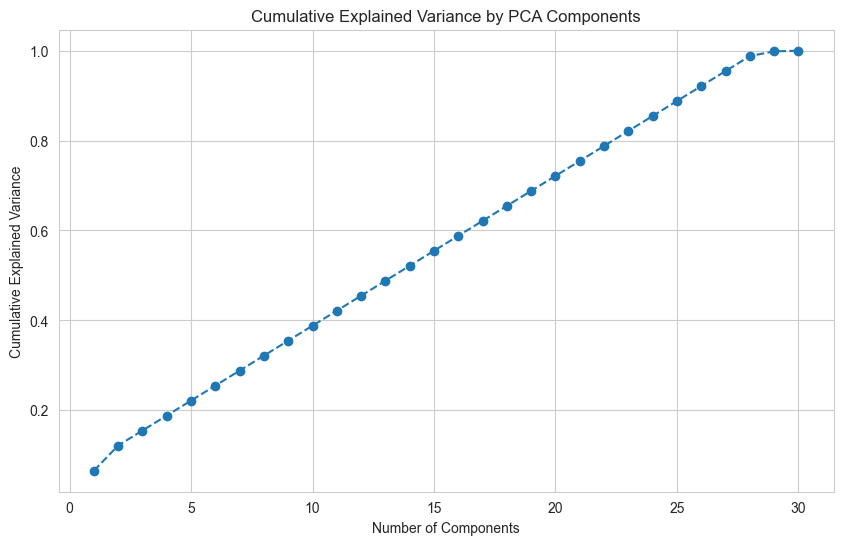

In [14]:
# Apply PCA without specifying the number of components
pca = PCA()
pca.fit(X)

# Calculate the cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

Based on the explained-variance profile, we retain the full standardized feature set for anomaly modeling to avoid discarding potentially informative variance relevant to rare-event detection.

## 7. Model Training and Quantitative Evaluation

We train two unsupervised anomaly detection models and evaluate their outputs against known labels (`Class`) for comparative analysis.

### Models compared
- `Isolation Forest`: isolates anomalies through random partitioning.
- `One-Class SVM`: learns a boundary around normal instances in feature space.

### Evaluation focus
Given class imbalance, we prioritize fraud recall, precision, and false-positive burden over raw accuracy.

In [15]:
# Train the Isolation Forest model
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=RANDOM_STATE)
y_pred_iso = iso_forest.fit_predict(X)

# The output of the model is -1 for anomalies (fraud) and 1 for inliers (non-fraud).
# We need to convert these to 1 for fraud and 0 for non-fraud to match our 'y_true' labels.
y_pred_iso[y_pred_iso == 1] = 0
y_pred_iso[y_pred_iso == -1] = 1

# Evaluate the model
print("Isolation Forest Classification Report:")
print(classification_report(y_true, y_pred_iso))

print("Isolation Forest Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_iso))

Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    284315
           1       0.04      0.82      0.08       492

    accuracy                           0.97    284807
   macro avg       0.52      0.89      0.53    284807
weighted avg       1.00      0.97      0.98    284807

Isolation Forest Confusion Matrix:
[[274823   9492]
 [    89    403]]


In [17]:
# Reduce dimensionality for speed/tractability of One-Class SVM on large datasets
# (Training RBF OneClassSVM on the full feature space is extremely slow.)
pca_svm = PCA(n_components=10, svd_solver="randomized", random_state=RANDOM_STATE)
X_svm = pca_svm.fit_transform(X)

# Train the One-Class SVM model on reduced features
one_class_svm = OneClassSVM(nu=0.01, kernel="rbf", gamma=0.01)
y_pred_svm = one_class_svm.fit_predict(X_svm)

# The output of the model is -1 for anomalies (fraud) and 1 for inliers (non-fraud).
# We need to convert these to 1 for fraud and 0 for non-fraud to match our 'y_true' labels.
y_pred_svm[y_pred_svm == 1] = 0
y_pred_svm[y_pred_svm == -1] = 1

# Evaluate the model
print("One-Class SVM Classification Report:")
print(classification_report(y_true, y_pred_svm))

print("One-Class SVM Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_svm))

One-Class SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.11      0.63      0.19       492

    accuracy                           0.99    284807
   macro avg       0.55      0.81      0.59    284807
weighted avg       1.00      0.99      0.99    284807

One-Class SVM Confusion Matrix:
[[281776   2539]
 [   183    309]]


## 8. Model Selection Discussion

Model selection in fraud detection is a cost-sensitive decision. Missing fraud (false negatives) and incorrectly blocking legitimate transactions (false positives) have different business costs.

### Comparative Decision Framework

**Isolation Forest**
- **Strength:** typically higher fraud recall (captures more true fraud events).
- **Trade-off:** may produce substantially more false positives.

**One-Class SVM**
- **Strength:** often fewer false positives and cleaner alert queue.
- **Trade-off:** lower fraud recall can increase undetected fraud loss.

### Selection Rationale
For fraud-risk management, missing fraud is often costlier than investigating additional alerts. Under that assumption, `Isolation Forest` is selected as the primary candidate, with the recommendation to tune contamination/thresholds for operational precision control.

## 9. Post-Model Behavioral Analysis

After selecting a candidate model, we inspect detected anomalies to understand their behavioral profile. This step improves trustworthiness and supports operational deployment decisions.

In [18]:
# Create a new column in the original dataframe with the Isolation Forest predictions
df['iso_forest_pred'] = y_pred_iso

# Create explicit copies to avoid chained-assignment side effects in later feature engineering
fraudulent_transactions = df[df['iso_forest_pred'] == 1].copy()
non_fraudulent_transactions = df[df['iso_forest_pred'] == 0].copy()

# Display representative anomaly records
display(fraudulent_transactions.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,iso_forest_pred
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0,1
82,52.0,-3.005237,2.600138,1.483691,-2.418473,0.306326,-0.824575,2.065426,-1.829347,4.009259,...,-0.181268,-0.163747,0.515821,0.136318,0.460054,-0.251259,-1.105751,1.46,0,1
83,53.0,-1.198968,-1.474100,1.840326,-4.515824,0.327567,-0.174469,0.959726,-1.026456,1.700435,...,0.334614,-0.364541,-0.310186,-0.302599,-1.243924,-1.123457,-0.734351,89.17,0,1
134,83.0,-1.897331,0.955626,0.052543,1.276656,-3.323084,3.229911,1.029631,1.515607,-0.059627,...,0.776078,0.477537,-0.608981,-1.120892,-0.413851,0.061399,-0.187964,552.18,0,1
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,...,-0.678879,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0,1


### Quantifying Detection Power

We compute recall on the fraud class to measure the proportion of true fraudulent transactions successfully detected by the selected anomaly model.


In [19]:
# Get the number of actual frauds that were correctly identified (True Positives)
true_positives = confusion_matrix(y_true, y_pred_iso)[1, 1]

# Get the number of actual frauds that were missed (False Negatives)
false_negatives = confusion_matrix(y_true, y_pred_iso)[1, 0]

# Calculate the percentage of actual fraud detected (recall)
recall = true_positives / (true_positives + false_negatives)

print(f"Percentage of actual fraud detected (Recall): {recall:.2%}")

Percentage of actual fraud detected (Recall): 81.91%


### Comparative Distribution: `Amount` Across Predicted Classes

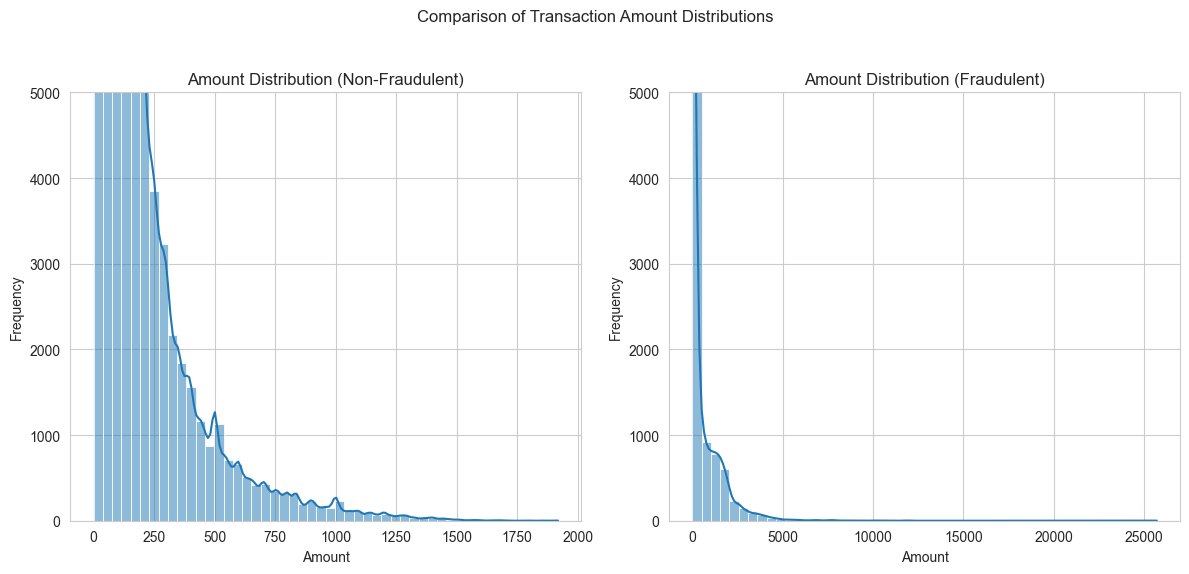

In [20]:
# Plotting the distribution of 'Amount' for both fraudulent and non-fraudulent transactions

plt.figure(figsize=(12, 6))

# Plot for non-fraudulent transactions
plt.subplot(1, 2, 1)
sns.histplot(non_fraudulent_transactions['Amount'], bins=50, kde=True)
plt.title('Amount Distribution (Non-Fraudulent)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.ylim(0, 5000) # Setting a y-limit to make the plot more readable

# Plot for fraudulent transactions
plt.subplot(1, 2, 2)
sns.histplot(fraudulent_transactions['Amount'], bins=50, kde=True)
plt.title('Amount Distribution (Fraudulent)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.ylim(0, 5000) # Setting the same y-limit for comparison

plt.suptitle('Comparison of Transaction Amount Distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretation of Amount Profiles

- Both predicted groups remain right-skewed, so small-value transactions dominate globally.
- The anomaly group exhibits a relatively heavier tail, indicating higher representation of larger transactions.
- `Amount` alone is not a definitive fraud indicator, but it contributes useful signal when combined with multidimensional patterns.

Research implication: robust fraud detection should treat amount as a contextual feature rather than a standalone rule.

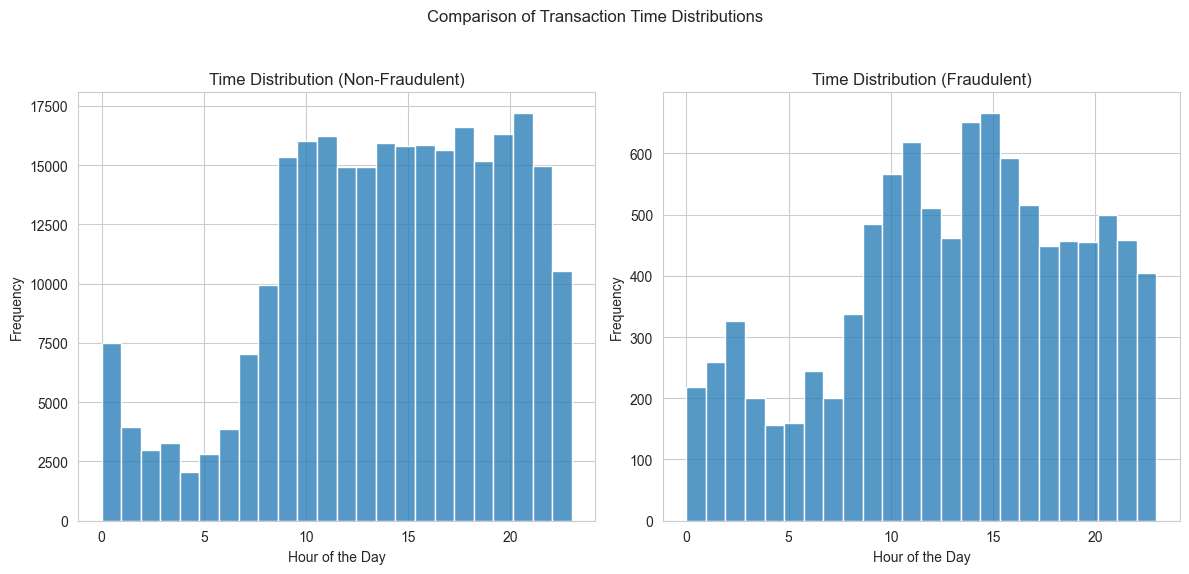

In [21]:
# Create hour-of-day features for temporal behavior comparison
df['Hour'] = np.floor(df['Time'] / 3600)
non_fraudulent_transactions['Hour'] = np.floor(non_fraudulent_transactions['Time'] / 3600)
fraudulent_transactions['Hour'] = np.floor(fraudulent_transactions['Time'] / 3600)

# Plotting the distribution of 'Hour' for both fraudulent and non-fraudulent transactions

plt.figure(figsize=(12, 6))

# Plot for non-fraudulent transactions
plt.subplot(1, 2, 1)
sns.histplot(non_fraudulent_transactions['Hour'] % 24, bins=24)
plt.title('Time Distribution (Non-Fraudulent)')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')

# Plot for fraudulent transactions
plt.subplot(1, 2, 2)
sns.histplot(fraudulent_transactions['Hour'] % 24, bins=24)
plt.title('Time Distribution (Fraudulent)')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')

plt.suptitle('Comparison of Transaction Time Distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 10. Final Findings, Limitations, and Future Work

### Key Findings
- Detected anomalies present a distinct **amount profile** with a comparatively heavier upper tail.
- Detected anomalies present a distinct **time profile**, including stronger activity during low-normal-traffic hours.
- Unsupervised modeling is effective for surfacing suspicious behavioral regions even without supervised training labels.

### Study Limitations
- Evaluation uses known labels offline; real-world deployment would require threshold calibration under changing fraud prevalence.
- The analysis uses default/near-default hyperparameters for initial comparison and may not represent peak performance.
- Temporal drift and adversarial adaptation are not modeled in this static snapshot.

### Future Work
- Hyperparameter optimization for contamination, kernel, and decision thresholds.
- Precision-recall curve analysis and cost-sensitive thresholding.
- Addition of robust temporal features and model monitoring for drift.

### Conclusion
This notebook demonstrates a research-oriented fraud detection workflow: rigorous EDA, principled preprocessing, comparative anomaly modeling, and behavior-level interpretation. The selected approach provides strong fraud-capture capability and a clear path to operational refinement.